In [1]:
import os

from loadData import data_pipe
os.environ['CUDA_VISIBLE_DEVICES'] = ','.join(map(str, [1]))
print('using GPU %s' % ','.join(map(str, [1])))

import torch
from torch.utils.data import DataLoader
from torch.optim.lr_scheduler import SequentialLR, StepLR, LambdaLR
from thop import profile, clever_format

import csv
import time
import json
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE
# plt.rc('font',family='Times New Roman') 

from option import opt
from loadData import data_pipe
from loadData.split_data import HyperX2
from loadData.dataAugmentation import DataAugmentation, DataAugmentation2

from models import vision_transformer, CNNBase, vision_transformer_dino
from models import automaticWeightedLoss, modules
from models.MS2CANet import pymodel
from utils import infoNCE,  focalLoss, orthogonalLoss, distillation, CELoss
from utils import trainer, tester, tools, visulization

using GPU 1


WARNING[XFORMERS]: xFormers can't load C++/CUDA extensions. xFormers was built for:
    PyTorch 2.7.1+cu126 with CUDA 1208 (you have 2.8.0+cu128)
    Python  3.9.23 (you have 3.10.13)
  Please reinstall xformers (see https://github.com/facebookresearch/xformers#installing-xformers)
  Memory-efficient attention, SwiGLU, sparse and more won't be available.
  Set XFORMERS_MORE_DETAILS=1 for more details
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/swiglu_ffn.py:51: UserWarning: xFormers is not available (SwiGLU)
  warnings.warn("xFormers is not available (SwiGLU)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/attention.py:33: UserWarning: xFormers is not available (Attention)
  warnings.warn("xFormers is not available (Attention)")
/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/models/layers/block.py:40: UserWarning: xFormers is not available (Block)
  warnings.warn("xFormers is not available (Block)")


In [2]:
args = opt.get_args()
args.dataset_name = "Houston_2013"
# args.dataset_name = "Houston_2018"
# args.dataset_name = "Berlin"

args.backbone = "resNet2"
# args.backbone = "MS2CANet"
# args.backbone = "vit_dino_s"

args.split_type = "ratio"
print("args.backbone", args.backbone)
# print("args.randomCrop", args.randomCrop)

args.epochs = 50
args.patch_size = 13
args.randomCrop = 11

# args.patch_size = 6
# args.randomCrop = 6
# args.randomCrop = 4
args.pca = True
# args.pca = False

args.lambda_orth = 0.1
args.lambda_kl = 0
args.step_size = 30
args.gamma = 0.7

# 加载已有权重路径
# args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/08-02-16-16-resNet2_Houston_2013"
args.result_dir = "/home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-08-resNet2_Houston_2013"

args.backbone resNet2


In [3]:
args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt, GT = data_pipe.get_data(args)
transform = [DataAugmentation(args), DataAugmentation2(args)]

args.mix = True
contrastive_dataset = HyperX2(img1, data2=img2, gt=data_gt, transform=transform, args=args)
contrastive_loader = DataLoader(contrastive_dataset, batch_size=args.batch_size, shuffle=True, drop_last=True)


# data_pipe.set_deterministic(seed = 666)
args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = True
args.train_ratio = 0.9

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt, GT = data_pipe.get_data(args)
band1 = img1.shape[2]
band2 = img2.shape[2]
args.min = str(np.min(img1))
args.max = str(np.max(img1))
print("img1", img1.shape, "img2", img2.shape, band1, band2, args.min, args.max)
print("train_gt", train_gt.shape, \
		"test_gt", test_gt.shape, \
		"data_gt", data_gt.shape, \
		"GT", GT.shape)


args.mix = False
train_dataset = HyperX2(img1, data2=img2, gt=train_gt, transform=transform, args=args)
val_dataset = HyperX2(img1, data2=img2, gt=val_gt, transform=None, args=args)
test_dataset = HyperX2(img1, data2=img2, gt=test_gt, transform=None, args=args)

# 用于 focalloss
train_gt_pure = train_gt[train_gt > 0] - 1
test_gt_pure = test_gt[test_gt > 0] - 1
loss_weight = focalLoss.loss_weight_calculation(test_gt_pure)

train_loader = DataLoader(train_dataset, batch_size=args.batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=args.batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=args.batch_size, shuffle=False)

class_num = np.max(train_gt)
print(class_num, train_gt.shape, len(train_loader.dataset))

pca is used
pca is used
img1 (363, 1919, 15) img2 (363, 1919, 1) 15 1 -61.004364 69.50995
train_gt (363, 1919) test_gt (363, 1919) data_gt (363, 1919) GT (349, 1905)
15 (363, 1919) 2549


In [4]:
if args.backbone == "resNet2":
    args.feature_dim = 512
    encoder = CNNBase.Model_base(channell=band1, channel2=band2).to(args.device)
    # args.feature_dim = 2048
    super_head = modules.FDGCHead(args.feature_dim, class_num=class_num).to(args.device)

elif args.backbone == "vit_dino_s":
    args.feature_dim = 384
    encoder = vision_transformer_dino.Vit_base(band1, band2, args.randomCrop).to(args.device)
    super_head = modules.FDGCHead(args.feature_dim, class_num=class_num).to(args.device)

elif args.backbone == "MS2CANet":
    FM = 64
    args.feature_dim = 256
    para_tune = False
    if args.dataset_name == "Houston_2013":
        para_tune = True                # para_tune 这个参数对于 Houston 的提升有两个点！！
    encoder = pymodel.pyCNN(FM=FM, NC=args.components, para_tune=para_tune).to(args.device)
    super_head = modules.MS2_head(args.feature_dim, class_num=class_num).to(args.device)

contra_head = modules.DINOHead(args.feature_dim).to(args.device)
awl = automaticWeightedLoss.AutomaticWeightedLoss(3).to(args.device)
params = list(super_head.parameters()) + list(encoder.parameters()) + list(contra_head.parameters())

optimizer = torch.optim.AdamW(params, lr=args.learning_rate, weight_decay=args.weight_decay)
warmup = LambdaLR(optimizer, lr_lambda=lambda e: min(1.0, e / 5.0))
decay = StepLR(optimizer, step_size=args.step_size, gamma=args.gamma)
# scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=args.step_size, gamma=args.gamma)  # 学习太快
scheduler = SequentialLR(optimizer, schedulers=[warmup, decay], milestones=[5])


# criterion0 = torch.nn.CrossEntropyLoss().to(args.device)
criterion1 = CELoss.LabelSmoothSoftmaxCEV1(lb_smooth=args.lb_smooth).to(args.device)
criterion2 = infoNCE.InfoNCE().to(args.device)
criterion3 = infoNCE.NT_xent_loss_W_EN().to(args.device)

criterion4 = distillation.distillation_loss().to(args.device)
criterion5 = orthogonalLoss.OrthogonalLoss(version='dot', sample_size=20).to(args.device)
loss_weight = loss_weight.to(args.device)
criterion6 = focalLoss.FocalLoss(loss_weight, gamma=2, alpha=None).to(args.device)

# 验证精度

In [5]:
args.resume = os.path.join(args.result_dir, "test_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=True)
    super_head.load_state_dict(checkpoint['super_head'], strict=True)
    contra_head.load_state_dict(checkpoint['contra_head'], strict=True)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0

# linear 精度
if args.backbone == "resNet2" or args.backbone == "vit_dino_s":
    test_loss, test_preds, targets, test_acc, test_time = \
        tester.test_resNet2(encoder, super_head, criterion1, test_loader, args) 
elif args.backbone == "MS2CANet":
    test_loss, test_preds, targets, test_acc, test_time = \
        tester.test_MS2CANet(encoder, super_head, criterion1, test_loader, args)
else:
    raise NotImplementedError("No models")
classification, kappa = tester.get_results(test_preds, targets)
print(classification)


with open(os.path.join(args.result_dir, "log_final.csv"), 'a+', encoding='gbk') as f:
    row=[["\nLinear Train",
        "\nepoch", epoch, 
        "\nclassification\n", classification,
        "\nkappa", kappa,
        "\nTest_time", round(test_time, 2),
        "\n"
        ]]
    write=csv.writer(f)
    for i in range(len(row)):
        write.writerow(row[i])

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-08-resNet2_Houston_2013/test_loss.pth epoch 45
              precision    recall  f1-score   support

           0     0.9977    0.8186    0.8993      1053
           1     0.9906    0.8957    0.9408      1064
           2     0.9816    0.9505    0.9658       505
           3     0.9812    0.9896    0.9854      1056
           4     1.0000    1.0000    1.0000      1056
           5     0.4325    0.9860    0.6013       143
           6     0.9095    0.9655    0.9367      1072
           7     0.9535    0.9744    0.9638      1053
           8     0.9925    0.9934    0.9929      1059
           9     0.9922    0.9768    0.9844      1036
          10     0.9704    0.9658    0.9681      1054
          11     0.9942    0.9875    0.9908      1041
          12     0.9394    0.9789    0.9588       285
          13     0.9081    1.0000    0.9518       247
          14     0.9489    0.9810    0.9647       473


# 绘图

Loaded from: /home/icclab/Documents/lqw/Multimodal_Classification/MoEIF/result/10-15-22-08-resNet2_Houston_2013/test_loss.pth epoch 45
pca is used


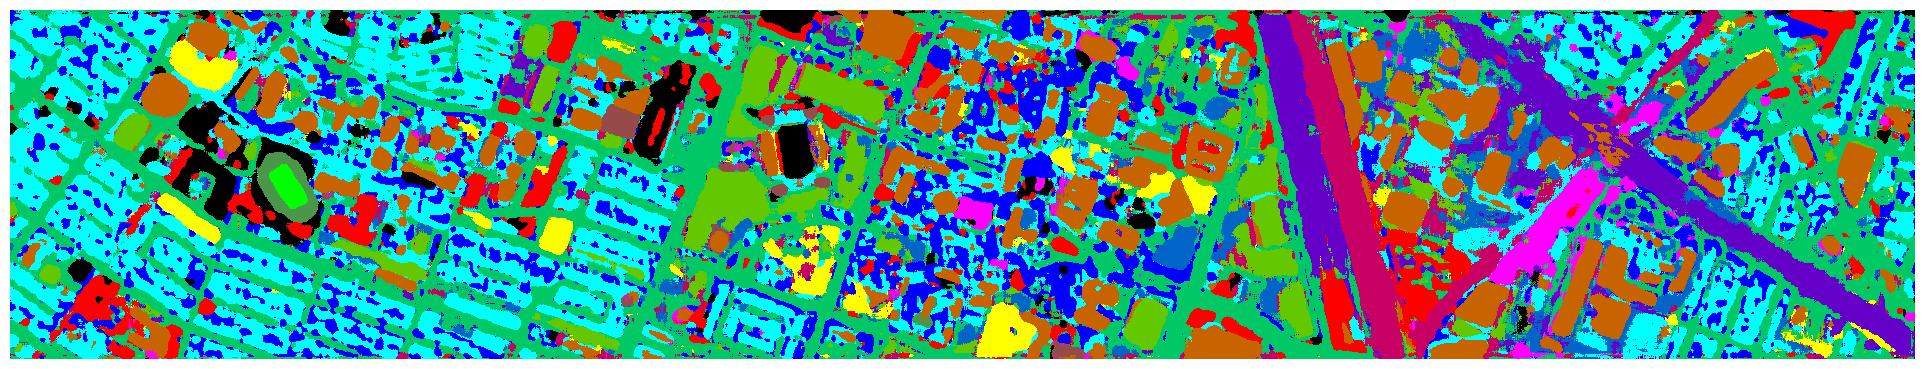

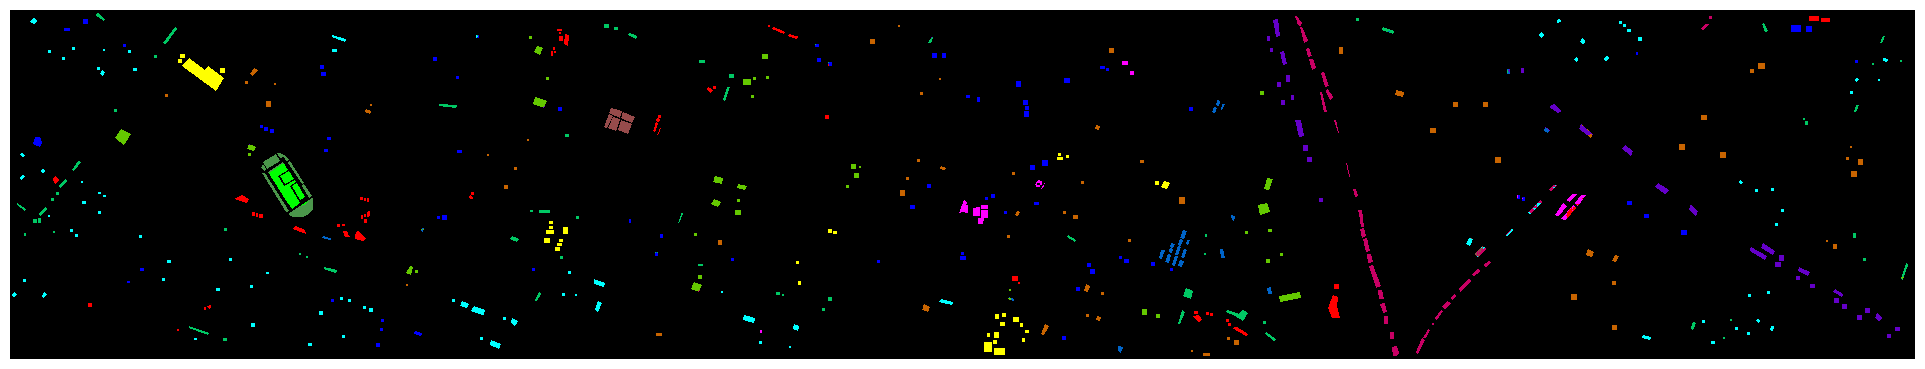

In [6]:
args.resume = os.path.join(args.result_dir, "test_loss.pth")
if args.resume != '':
    checkpoint = torch.load(args.resume)
    encoder.load_state_dict(checkpoint['model'], strict=False)
    super_head.load_state_dict(checkpoint['super_head'], strict=False)
    contra_head.load_state_dict(checkpoint['contra_head'], strict=False)
    epoch = checkpoint['epoch'] + 1
    print('Loaded from: {} epoch {}'.format(args.resume, epoch))
else:
    epoch_start = 0

args.print_data_info = False
args.data_info_start = 1
args.show_gt = False
args.remove_zero_labels = False
args.train_ratio = 1

# create dataloader
img1, img2, train_gt, val_gt, test_gt, data_gt, groundTruth = data_pipe.get_data(args)
# transform = DataAugmentation(args)

data_dataset = HyperX2(img1, data2=img2, gt=data_gt, transform=None, args=args)
data_loader = DataLoader(data_dataset, batch_size=args.batch_size, shuffle=False, drop_last=False)

visulization.test_visulization(encoder, super_head, data_loader, args, groundTruth) 